In [1]:
# ============================================================
# 1. Importar librerías
# ============================================================
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

# Visualización bonita
sns.set(style="whitegrid")

In [2]:
# 2. Cargar los datos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# 2. Cargar dataset y seleccionar variables NUMÉRICAS
# ============================================================
url = '/content/drive/MyDrive/nacimientos/Serie_Nacimientos_2001_2019.csv'
df = pd.read_csv(url, sep=";")
df.head()

# Selección de variables numéricas apropiadas para clustering
variables = [
    "SEMANAS",
    "TALLA"
]

df_num = df[variables].dropna()

print("Dimensiones dataset numérico:", df_num.shape)

Dimensiones dataset numérico: (2990720, 2)


In [9]:
print(df.head())

   MES_NAC  ANO_NAC  SEXO  TIPO_PARTO  TIPO_ATEN  PARTO_LOCAL  SEMANAS  \
0        1     2001     1           1          1            1      NaN   
1        1     2001     1           1          1            1      NaN   
2        1     2001     1           1          1            1      NaN   
3        1     2001     1           1          1            1     24.0   
4        1     2001     1           1          1            1     24.0   

    RANGO_PESO  TALLA GRUPO_ETARIO_PADRE  ...  GRUPO_ETARIO_MADRE  \
0  1500 - 2499   46.0       30 A 34 AÑOS  ...        30 A 34 AÑOS   
1  3000 - 3999   50.0       30 A 34 AÑOS  ...        30 A 34 AÑOS   
2  3000 - 3999   53.0       30 A 34 AÑOS  ...        30 A 34 AÑOS   
3        <1500   29.0       25 A 29 AÑOS  ...        15 A 19 AÑOS   
4        <1500   30.0       40 A 44 AÑOS  ...        35 A 39 AÑOS   

   EST_CIV_MADRE  CURSO_MADRE NIVEL_MADRE  ACTIV_MADRE OCUPA_MADRE  \
0            2.0          4.0         1.0          1.0           3   


In [4]:
# ============================================================
# 3. Escalado
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

In [5]:
# Tomar muestra para acelerar el clustering
df_sample = df_num.sample(n=50000, random_state=42)

# Escalado nuevamente pero sobre la muestra
X_scaled_sample = scaler.fit_transform(df_sample)


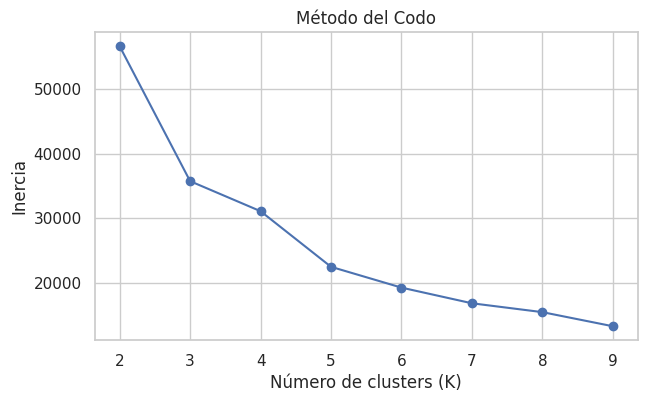


K-MEANS MÉTRICAS:
Silhouette Score: 0.39807139911693384
Davies-Bouldin: 0.8261698620272441
Calinski-Harabasz: 44961.225031362446


In [7]:
# ============================================================
# 4. CLUSTERING 1: K-MEANS (rápido)
# ============================================================

# ---- Método del CODO ----
inertias = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, inertias, marker="o")
plt.title("Método del Codo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.show()

# ---- Elegir K óptimo ----
k_optimo = 3  # puedes ajustar según el gráfico

kmeans = KMeans(n_clusters=k_optimo, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled_sample)

print("\nK-MEANS MÉTRICAS:")
print("Silhouette Score:", silhouette_score(X_scaled_sample, labels_kmeans))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled_sample, labels_kmeans))
print("Calinski-Harabasz:", calinski_harabasz_score(X_scaled_sample, labels_kmeans))

In [8]:
# ============================================================
# 5. CLUSTERING 2: DBSCAN (muestra para velocidad)
# ============================================================
df_sample_dbscan = df_num.sample(n=20000, random_state=42)
X_dbscan = scaler.fit_transform(df_sample_dbscan)

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_db = dbscan.fit_predict(X_dbscan)

# Filtrar ruido (-1)
mask = labels_db != -1
labels_db_clean = labels_db[mask]
X_clean = X_dbscan[mask]

print("\nDBSCAN MÉTRICAS (clusters sin ruido):")
print("Silhouette Score:", silhouette_score(X_clean, labels_db_clean))
print("Davies-Bouldin:", davies_bouldin_score(X_clean, labels_db_clean))
print("Calinski-Harabasz:", calinski_harabasz_score(X_clean, labels_db_clean))


DBSCAN MÉTRICAS (clusters sin ruido):
Silhouette Score: 0.2115261560057896
Davies-Bouldin: 1.7406038155840633
Calinski-Harabasz: 3451.682150988168
